# Install and Import Libraries

In [1]:
# Install required packages
!pip install nibabel scikit-image -q

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import nibabel as nib
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")
print("="*70)

2025-11-04 12:07:01.614715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762258021.843284      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762258021.920658      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ ALL LIBRARIES IMPORTED SUCCESSFULLY
TensorFlow Version: 2.18.0
GPU Available: 2 GPU(s)


# Configuration

In [ ]:
# Configuration
class Config:
    # Paths
    DATA_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation'
    TRAIN_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData'
    VAL_PATH =  '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_ValidationData'
    
    # Preprocessed data paths
    PROCESSED_PATH = '/kaggle/working/processed_data'
    TRAIN_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'train_images.npy')
    TRAIN_MASKS_PATH = os.path.join(PROCESSED_PATH, 'train_masks.npy')
    VAL_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'val_images.npy')
    VAL_MASKS_PATH = os.path.join(PROCESSED_PATH, 'val_masks.npy')
    TEST_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'test_images.npy')
    TEST_MASKS_PATH = os.path.join(PROCESSED_PATH, 'test_masks.npy')
    
    # Model parameters
    IMG_SIZE = 128
    CHANNELS = 4  # T1, T1ce, T2, FLAIR
    NUM_CLASSES = 4  # 0: background, 1: necrotic, 2: edema, 3: enhancing
    BATCH_SIZE = 16
    EPOCHS = 80
    LEARNING_RATE = 0.0001
    
    # Training parameters - PATIENT-LEVEL SPLIT (NO DATA LEAKAGE!)
    TRAIN_SPLIT = 0.70      # 70% patients for training
    VAL_SPLIT = 0.15        # 15% patients for validation
    TEST_SPLIT = 0.15       # 15% patients for testing
    SLICE_RANGE = (30, 120)  # Extract slices from this range
    
config = Config()
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Channels: {config.CHANNELS}")
print(f"Number of Classes: {config.NUM_CLASSES}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Epochs: {config.EPOCHS}")
print(f"\n📊 Data Split Strategy (PATIENT-LEVEL - No Leakage!):")
print(f"   Train: {config.TRAIN_SPLIT*100:.0f}% of patients")
print(f"   Validation: {config.VAL_SPLIT*100:.0f}% of patients")
print(f"   Test: {config.TEST_SPLIT*100:.0f}% of patients")
print(f"\n⚠️  IMPORTANT: Split happens at PATIENT level BEFORE slice extraction")
print(f"   This prevents data leakage between train/val/test sets")
print("="*70)

CONFIGURATION
Image Size: 128x128
Channels: 4
Number of Classes: 4
Batch Size: 16
Epochs: 50

📊 Data Split Strategy (PATIENT-LEVEL - No Leakage!):
   Train: 70% of patients
   Validation: 15% of patients
   Test: 15% of patients

⚠️  IMPORTANT: Split happens at PATIENT level BEFORE slice extraction
   This prevents data leakage between train/val/test sets


#  Data Loading Functions

In [3]:
 def load_nifti(filepath):
    """Load NIfTI file and return numpy array"""
    return nib.load(filepath).get_fdata()

def get_patient_paths(base_path):
    """Get all patient directories"""
    patient_dirs = sorted(glob(os.path.join(base_path, 'BraTS20_*')))
    return patient_dirs

def load_patient_data(patient_dir):
    """Load all modalities and mask for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Load mask (seg file)
    mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    
    # Stack modalities
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    return image, mask

def convert_mask_labels(mask):
    """Convert label 4 to label 3"""
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


# Split Patients

In [4]:
# ============================================================================
# STEP 1: SPLIT PATIENTS FIRST (CRITICAL FOR PREVENTING DATA LEAKAGE!)
# ============================================================================

print("="*70)
print("STEP 1: SPLITTING PATIENTS (BEFORE EXTRACTING SLICES)")
print("="*70)

# Get all patient directories
all_patients = get_patient_paths(config.TRAIN_PATH)
print(f"\nTotal patients available: {len(all_patients)}")

# Split patients into train/val/test at PATIENT LEVEL
# First split: separate test patients (15%)
train_val_patients, test_patients = train_test_split(
    all_patients,
    test_size=config.TEST_SPLIT,
    random_state=42,
    shuffle=True
)

# Second split: separate train and validation from remaining 85%
val_size_adjusted = config.VAL_SPLIT / (config.TRAIN_SPLIT + config.VAL_SPLIT)
train_patients, val_patients = train_test_split(
    train_val_patients,
    test_size=val_size_adjusted,
    random_state=42,
    shuffle=True
)

print(f"\n📊 PATIENT-LEVEL SPLIT:")
print(f"   Train patients: {len(train_patients)} ({len(train_patients)/len(all_patients)*100:.1f}%)")
print(f"   Validation patients: {len(val_patients)} ({len(val_patients)/len(all_patients)*100:.1f}%)")
print(f"   Test patients: {len(test_patients)} ({len(test_patients)/len(all_patients)*100:.1f}%)")
print(f"   Total: {len(all_patients)} patients")

print(f"\n✅ CRITICAL: No patient appears in multiple sets!")
print(f"   This prevents data leakage and ensures valid evaluation.")

# Verify no overlap
train_set = set([os.path.basename(p) for p in train_patients])
val_set = set([os.path.basename(p) for p in val_patients])
test_set = set([os.path.basename(p) for p in test_patients])

assert len(train_set & val_set) == 0, "❌ Data leakage: Train and Val overlap!"
assert len(train_set & test_set) == 0, "❌ Data leakage: Train and Test overlap!"
assert len(val_set & test_set) == 0, "❌ Data leakage: Val and Test overlap!"

print(f"✅ Verified: No overlap between splits!")
print("="*70)

STEP 1: SPLITTING PATIENTS (BEFORE EXTRACTING SLICES)

Total patients available: 369

📊 PATIENT-LEVEL SPLIT:
   Train patients: 257 (69.6%)
   Validation patients: 56 (15.2%)
   Test patients: 56 (15.2%)
   Total: 369 patients

✅ CRITICAL: No patient appears in multiple sets!
   This prevents data leakage and ensures valid evaluation.
✅ Verified: No overlap between splits!


# 2D Slice Extraction and Preprocessing Functions

In [5]:
def extract_2d_slices(image_3d, mask_3d, slice_range=(30, 120)):
    """Extract 2D slices from 3D volume"""
    slices_images = []
    slices_masks = []
    
    for slice_idx in range(slice_range[0], min(slice_range[1], image_3d.shape[2])):
        # Extract slice
        img_slice = image_3d[:, :, slice_idx, :]
        mask_slice = mask_3d[:, :, slice_idx]
        
        # Skip if mask is empty (no tumor)
        if np.sum(mask_slice) > 0:
            slices_images.append(img_slice)
            slices_masks.append(mask_slice)
    
    return slices_images, slices_masks

def preprocess_image(image, target_size=128):
    """Resize and normalize image"""
    # Resize
    resized = cv2.resize(image, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    
    # Normalize each channel independently
    normalized = np.zeros_like(resized)
    for i in range(resized.shape[-1]):
        channel = resized[:, :, i]
        if np.max(channel) > 0:
            normalized[:, :, i] = (channel - np.min(channel)) / (np.max(channel) - np.min(channel))
    
    return normalized.astype(np.float32)

def preprocess_mask(mask, target_size=128):
    """Resize mask"""
    resized = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return resized.astype(np.uint8)

print("✅ Slice extraction and preprocessing functions defined!")

✅ Slice extraction and preprocessing functions defined!


# Process Each Split Separately

In [6]:
def process_patient_list(patient_list, split_name):
    """Process a list of patients and extract slices"""
    print(f"\n{'='*70}")
    print(f"Processing {split_name} Set ({len(patient_list)} patients)")
    print(f"{'='*70}")
    
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_list, desc=f"Processing {split_name}"):
        try:
            # Load patient data
            image_3d, mask_3d = load_patient_data(patient_dir)
            
            # Convert mask labels (4 → 3)
            mask_3d = convert_mask_labels(mask_3d)
            
            # Extract 2D slices
            slices_img, slices_mask = extract_2d_slices(image_3d, mask_3d, config.SLICE_RANGE)
            
            # Preprocess each slice
            for img_slice, mask_slice in zip(slices_img, slices_mask):
                processed_img = preprocess_image(img_slice, config.IMG_SIZE)
                processed_mask = preprocess_mask(mask_slice, config.IMG_SIZE)
                
                all_images.append(processed_img)
                all_masks.append(processed_mask)
        
        except Exception as e:
            print(f"\n❌ Error processing {patient_dir}: {e}")
            continue
    
    # Convert to numpy arrays
    all_images = np.array(all_images, dtype=np.float32)
    all_masks = np.array(all_masks, dtype=np.uint8)
    
    print(f"✅ {split_name} set processed: {len(all_images)} slices")
    
    return all_images, all_masks

# ============================================================================
# STEP 2: PROCESS EACH SPLIT SEPARATELY (NO DATA LEAKAGE!)
# ============================================================================

print("\n" + "="*70)
print("STEP 2: EXTRACTING SLICES FROM EACH SPLIT")
print("="*70)
print("Processing happens AFTER patient-level split → No data leakage!")

# Process training patients
train_images, train_masks = process_patient_list(train_patients, "TRAIN")

# Process validation patients
val_images, val_masks = process_patient_list(val_patients, "VALIDATION")

# Process test patients
test_images, test_masks = process_patient_list(test_patients, "TEST")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*70)
print("DATA PROCESSING COMPLETE - NO DATA LEAKAGE!")
print("="*70)
print(f"\n📊 PATIENT-LEVEL SPLIT:")
print(f"   Train: {len(train_patients)} patients")
print(f"   Validation: {len(val_patients)} patients")
print(f"   Test: {len(test_patients)} patients")

print(f"\n📊 SLICE-LEVEL RESULTS:")
print(f"   Train slices: {len(train_images):,}")
print(f"   Validation slices: {len(val_images):,}")
print(f"   Test slices: {len(test_images):,}")
print(f"   Total slices: {len(train_images) + len(val_images) + len(test_images):,}")

print(f"\n📊 DATA SHAPES:")
print(f"   Images shape: {train_images.shape}")
print(f"   Masks shape: {train_masks.shape}")

print(f"\n✅ VERIFICATION:")
print(f"   ✓ Patients split BEFORE slice extraction")
print(f"   ✓ No patient appears in multiple sets")
print(f"   ✓ No data leakage between train/val/test")
print(f"   ✓ Model has NEVER seen validation/test patients during training")

print("="*70)


STEP 2: EXTRACTING SLICES FROM EACH SPLIT
Processing happens AFTER patient-level split → No data leakage!

Processing TRAIN Set (257 patients)


Processing TRAIN: 100%|██████████| 257/257 [05:09<00:00,  1.20s/it]


✅ TRAIN set processed: 15412 slices

Processing VALIDATION Set (56 patients)


Processing VALIDATION: 100%|██████████| 56/56 [00:59<00:00,  1.07s/it]


✅ VALIDATION set processed: 3530 slices

Processing TEST Set (56 patients)


Processing TEST: 100%|██████████| 56/56 [00:58<00:00,  1.05s/it]


✅ TEST set processed: 3386 slices

DATA PROCESSING COMPLETE - NO DATA LEAKAGE!

📊 PATIENT-LEVEL SPLIT:
   Train: 257 patients
   Validation: 56 patients
   Test: 56 patients

📊 SLICE-LEVEL RESULTS:
   Train slices: 15,412
   Validation slices: 3,530
   Test slices: 3,386
   Total slices: 22,328

📊 DATA SHAPES:
   Images shape: (15412, 128, 128, 4)
   Masks shape: (15412, 128, 128)

✅ VERIFICATION:
   ✓ Patients split BEFORE slice extraction
   ✓ No patient appears in multiple sets
   ✓ No data leakage between train/val/test
   ✓ Model has NEVER seen validation/test patients during training


# Save Processed Data

In [7]:
# Save processed data
print("\n" + "="*70)
print("SAVING PROCESSED DATA")
print("="*70)

np.save(config.TRAIN_IMAGES_PATH, train_images)
np.save(config.TRAIN_MASKS_PATH, train_masks)
print(f"✅ Train data saved")

np.save(config.VAL_IMAGES_PATH, val_images)
np.save(config.VAL_MASKS_PATH, val_masks)
print(f"✅ Validation data saved")

np.save(config.TEST_IMAGES_PATH, test_images)
np.save(config.TEST_MASKS_PATH, test_masks)
print(f"✅ Test data saved")

print(f"\n💾 All data saved to: {config.PROCESSED_PATH}")
print("="*70)


SAVING PROCESSED DATA
✅ Train data saved
✅ Validation data saved
✅ Test data saved

💾 All data saved to: /kaggle/working/processed_data


# Load Processed Data

In [8]:
# ============================================================================
# LOAD PREPROCESSED DATA (Use this in future runs to skip preprocessing)
# ============================================================================

# Uncomment these lines if data is already processed:
# print("Loading preprocessed data...")
# train_images = np.load(config.TRAIN_IMAGES_PATH)
# train_masks = np.load(config.TRAIN_MASKS_PATH)
# val_images = np.load(config.VAL_IMAGES_PATH)
# val_masks = np.load(config.VAL_MASKS_PATH)
# test_images = np.load(config.TEST_IMAGES_PATH)
# test_masks = np.load(config.TEST_MASKS_PATH)

print("="*70)
print("DATA SUMMARY")
print("="*70)
print(f"Train images: {train_images.shape}")
print(f"Train masks: {train_masks.shape}")
print(f"Val images: {val_images.shape}")
print(f"Val masks: {val_masks.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test masks: {test_masks.shape}")

# Check class distribution
unique, counts = np.unique(train_masks, return_counts=True)
class_dist = dict(zip(unique, counts))
print(f"\n📊 Class distribution in training set:")
for cls, count in class_dist.items():
    print(f"   Class {cls}: {count:,} pixels ({count/train_masks.size*100:.2f}%)")
print("="*70)

DATA SUMMARY
Train images: (15412, 128, 128, 4)
Train masks: (15412, 128, 128)
Val images: (3530, 128, 128, 4)
Val masks: (3530, 128, 128)
Test images: (3386, 128, 128, 4)
Test masks: (3386, 128, 128)

📊 Class distribution in training set:
   Class 0: 245,653,245 pixels (97.28%)
   Class 1: 1,499,857 pixels (0.59%)
   Class 2: 3,957,708 pixels (1.57%)
   Class 3: 1,399,398 pixels (0.55%)


# Visualize Sample Data

VISUALIZING SAMPLES FROM EACH SPLIT

📊 Training Set Samples:


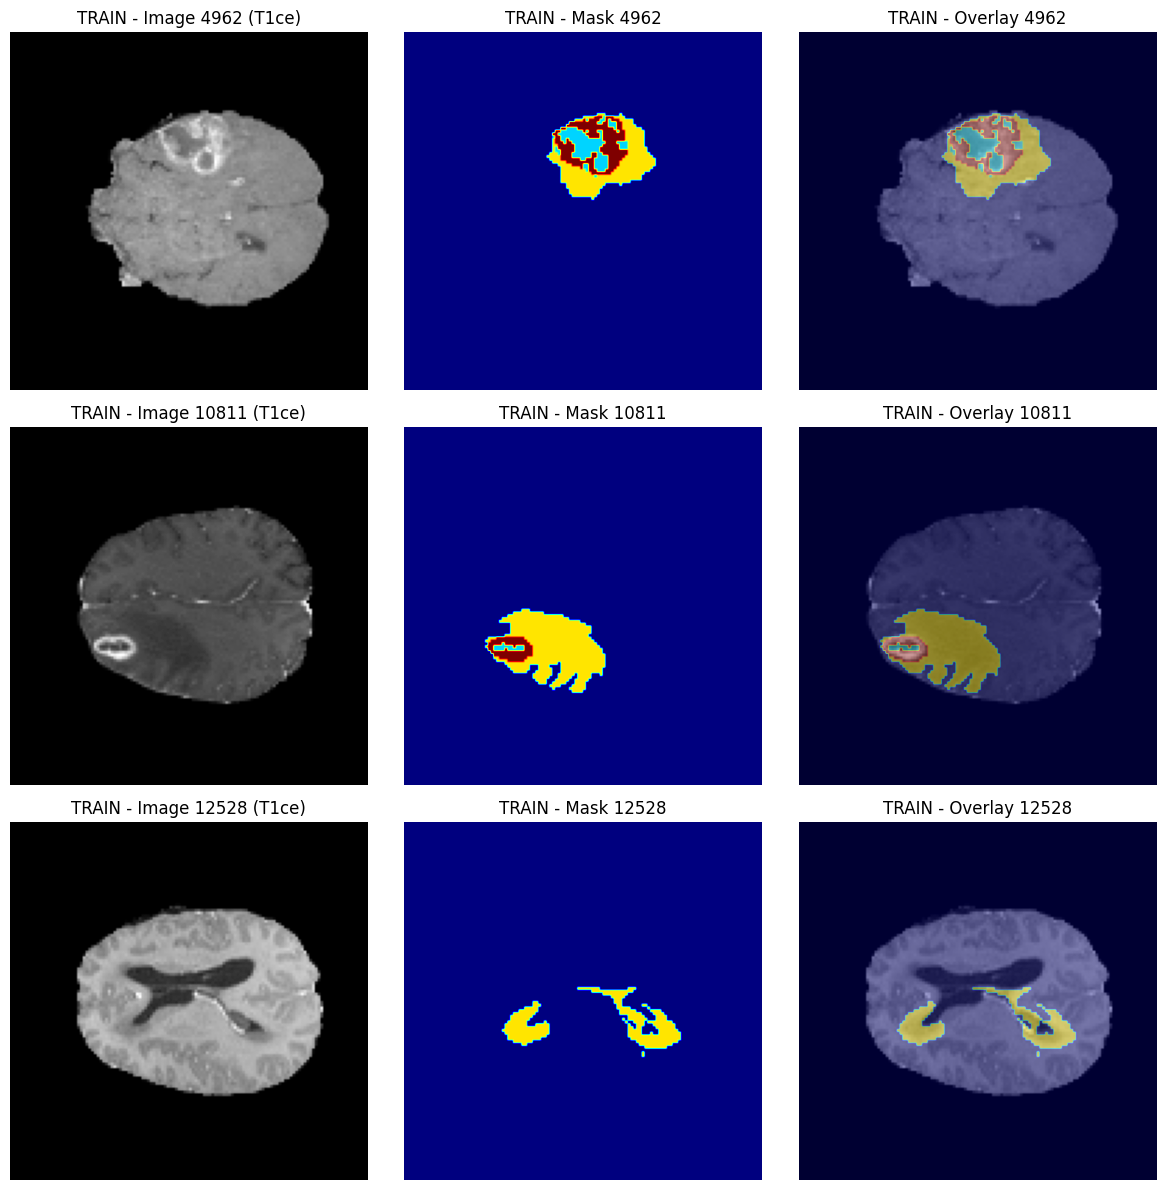


📊 Validation Set Samples:


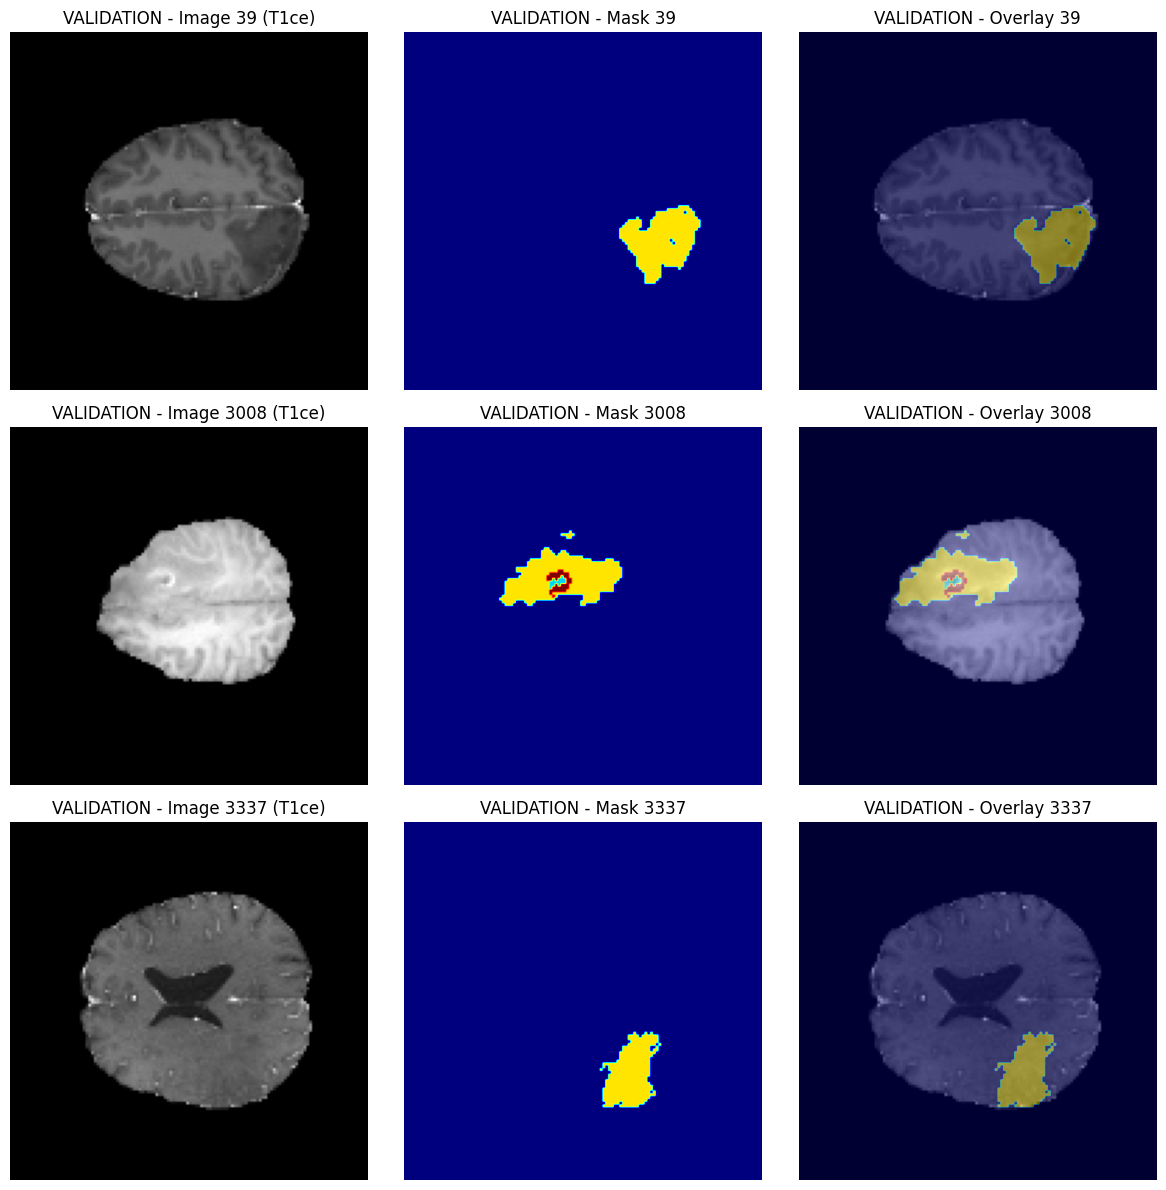


📊 Test Set Samples:


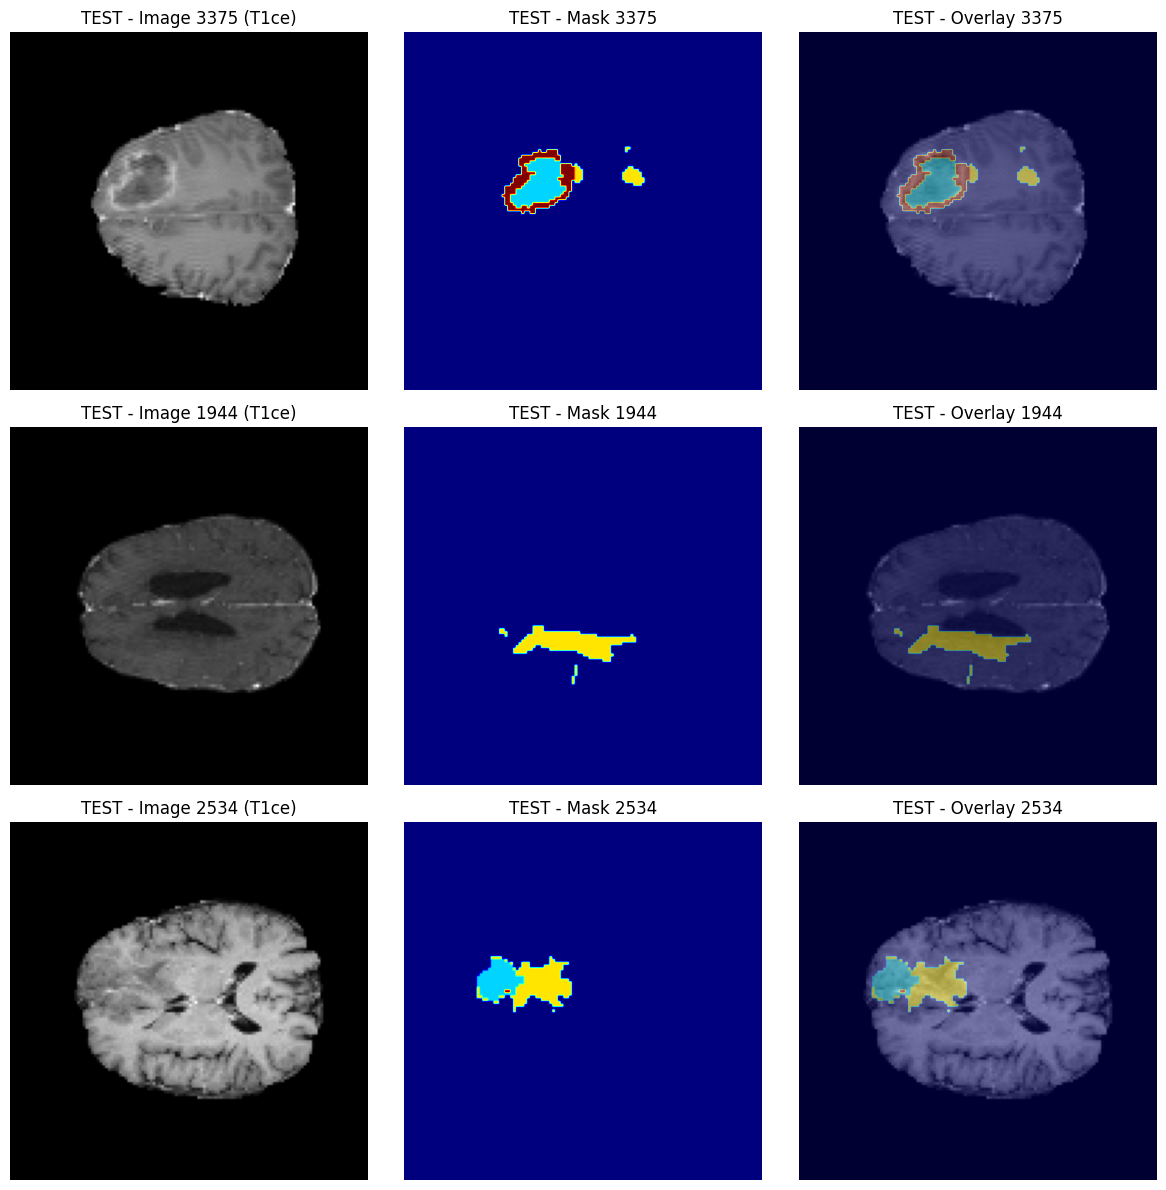

In [9]:
# Visualize samples from each split
def visualize_split_samples(images, masks, split_name, num_samples=3):
    """Visualize samples from a split"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        # Original image (T1ce channel)
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'{split_name} - Image {idx} (T1ce)')
        axes[i, 0].axis('off')
        
        # Mask
        axes[i, 1].imshow(masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title(f'{split_name} - Mask {idx}')
        axes[i, 1].axis('off')
        
        # Overlay
        axes[i, 2].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 2].imshow(masks[idx], cmap='jet', alpha=0.4, vmin=0, vmax=3)
        axes[i, 2].set_title(f'{split_name} - Overlay {idx}')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("="*70)
print("VISUALIZING SAMPLES FROM EACH SPLIT")
print("="*70)

print("\n📊 Training Set Samples:")
visualize_split_samples(train_images, train_masks, "TRAIN", num_samples=3)

print("\n📊 Validation Set Samples:")
visualize_split_samples(val_images, val_masks, "VALIDATION", num_samples=3)

print("\n📊 Test Set Samples:")
visualize_split_samples(test_images, test_masks, "TEST", num_samples=3)

# Data Augmentation

In [10]:
def augment_data(image, mask):
    """Apply random augmentation"""
    image = np.array(image, dtype=np.float32)
    mask = np.array(mask, dtype=np.uint8)
    
    # Random horizontal flip
    if np.random.random() > 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)
    
    # Random vertical flip
    if np.random.random() > 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)
    
    # Random rotation (90, 180, 270 degrees)
    k = np.random.randint(0, 4)
    if k > 0:
        image = np.rot90(image, k)
        mask = np.rot90(mask, k)
    
    # Random brightness adjustment
    if np.random.random() > 0.5:
        factor = np.random.uniform(0.8, 1.2)
        image = np.clip(image * factor, 0, 1)
    
    return image.astype(np.float32), mask.astype(np.uint8)

# Data Generator
class DataGenerator(Sequence):
    def __init__(self, images, masks, batch_size=16, num_classes=4, augment=False, shuffle=True):
        self.images = images
        self.masks = masks
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.indices))
        batch_indices = self.indices[start_idx:end_idx]
        
        batch_size_actual = len(batch_indices)
        batch_images = np.zeros((batch_size_actual, *self.images.shape[1:]), dtype=np.float32)
        batch_masks = np.zeros((batch_size_actual, *self.masks.shape[1:]), dtype=np.uint8)
        
        for i, idx in enumerate(batch_indices):
            img = self.images[idx].copy()
            mask = self.masks[idx].copy()
            
            if self.augment:
                img, mask = augment_data(img, mask)
            
            batch_images[i] = img
            batch_masks[i] = mask
        
        batch_masks_categorical = tf.keras.utils.to_categorical(batch_masks, num_classes=self.num_classes)
        
        return batch_images, batch_masks_categorical
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create data generators
train_gen = DataGenerator(train_images, train_masks, batch_size=config.BATCH_SIZE, 
                          num_classes=config.NUM_CLASSES, augment=True, shuffle=True)
val_gen = DataGenerator(val_images, val_masks, batch_size=config.BATCH_SIZE, 
                        num_classes=config.NUM_CLASSES, augment=False, shuffle=False)

print("="*70)
print("DATA GENERATORS CREATED")
print("="*70)
print(f"Training batches per epoch: {len(train_gen)}")
print(f"Validation batches per epoch: {len(val_gen)}")

# Test generator
sample_batch_x, sample_batch_y = train_gen[0]
print(f"\n✅ Generator test passed!")
print(f"Batch images shape: {sample_batch_x.shape}")
print(f"Batch masks shape: {sample_batch_y.shape}")
print("="*70)

DATA GENERATORS CREATED
Training batches per epoch: 964
Validation batches per epoch: 221

✅ Generator test passed!
Batch images shape: (16, 128, 128, 4)
Batch masks shape: (16, 128, 128, 4)


# Build U-Net Model

In [11]:
def conv_block(inputs, num_filters):
    """Convolutional block for U-Net"""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    return x

def encoder_block(inputs, num_filters):
    """Encoder block"""
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p

def decoder_block(inputs, skip_features, num_filters):
    """Decoder block"""
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)
    x = layers.Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape=(128, 128, 4), num_classes=4):
    """Build U-Net model"""
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)
    
    # Bridge
    b1 = conv_block(p4, 1024)
    
    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    # Output
    outputs = layers.Conv2D(num_classes, 1, padding='same', activation='softmax')(d4)
    
    model = models.Model(inputs, outputs, name='U-Net')
    return model

# Build model
model = build_unet(input_shape=(config.IMG_SIZE, config.IMG_SIZE, config.CHANNELS), 
                   num_classes=config.NUM_CLASSES)

print("="*70)
print("U-NET MODEL BUILT")
print("="*70)
model.summary()

I0000 00:00:1762258494.602879      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762258494.604412      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


U-NET MODEL BUILT


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,056,068 (118.47 MB)

 Trainable params: 31,044,292 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# Loss Functions and Metrics

In [12]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for multi-class segmentation"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice loss"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return 1 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """Combined Dice and Categorical Crossentropy loss"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    dice = dice_loss(y_true, y_pred)
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return dice + tf.reduce_mean(ce)

def iou_score(y_true, y_pred, smooth=1e-6):
    """Intersection over Union"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(y_true, y_pred):
    """Pixel-wise accuracy"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_class = tf.argmax(y_true, axis=-1)
    y_pred_class = tf.argmax(y_pred, axis=-1)
    correct = tf.cast(tf.equal(y_true_class, y_pred_class), tf.float32)
    return tf.reduce_mean(correct)

print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


# Compile Model

In [13]:
model.compile(
    optimizer=Adam(learning_rate=config.LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coefficient, iou_score, pixel_accuracy, 'categorical_accuracy']
)

print("="*70)
print("MODEL COMPILED")
print("="*70)
print(f"Optimizer: Adam (lr={config.LEARNING_RATE})")
print(f"Loss: Combined (Dice + Categorical Crossentropy)")
print(f"Metrics: Dice, IoU, Pixel Accuracy, Categorical Accuracy")
print("="*70)

MODEL COMPILED
Optimizer: Adam (lr=0.0001)
Loss: Combined (Dice + Categorical Crossentropy)
Metrics: Dice, IoU, Pixel Accuracy, Categorical Accuracy


# Callbacks

In [14]:
# ModelCheckpoint
checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/best_unet_model.h5',
    monitor='val_dice_coefficient',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Custom epoch summary callback
class EpochSummaryCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"{'='*70}")
        print(f"Epoch {epoch+1} Summary:")
        print(f"  Train → Loss: {logs['loss']:.4f} | Dice: {logs['dice_coefficient']:.4f} | IoU: {logs['iou_score']:.4f}")
        print(f"  Val   → Loss: {logs['val_loss']:.4f} | Dice: {logs['val_dice_coefficient']:.4f} | IoU: {logs['val_iou_score']:.4f}")
        print(f"{'='*70}\n")

epoch_summary = EpochSummaryCallback()

callbacks = [checkpoint, early_stopping, reduce_lr, epoch_summary]

print("="*70)
print("CALLBACKS CONFIGURED")
print("="*70)
print("✓ ModelCheckpoint: Saves best model")
print("✓ EarlyStopping: Stops if no improvement for 5 epochs")
print("✓ ReduceLROnPlateau: Reduces LR when plateaus")
print("✓ EpochSummaryCallback: Clean epoch summaries")
print("="*70)

CALLBACKS CONFIGURED
✓ ModelCheckpoint: Saves best model
✓ EarlyStopping: Stops if no improvement for 5 epochs
✓ ReduceLROnPlateau: Reduces LR when plateaus
✓ EpochSummaryCallback: Clean epoch summaries


# Training

In [15]:
print("STARTING TRAINING")
print("="*70)
print(f"Epochs: {config.EPOCHS}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Training samples: {len(train_images):,}")
print(f"Validation samples: {len(val_images):,}")
print(f"Training batches per epoch: {len(train_gen)}")
print(f"Validation batches per epoch: {len(val_gen)}")
print("="*70)
history = model.fit(
train_gen,
validation_data=val_gen,
epochs=config.EPOCHS,
callbacks=callbacks,
verbose=1  # Clean epoch-level output
)
print("\n" + "="*70)
print("✅ TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)

STARTING TRAINING
Epochs: 50
Batch size: 16
Training samples: 15,412
Validation samples: 3,530
Training batches per epoch: 964
Validation batches per epoch: 221
Epoch 1/50


I0000 00:00:1762258513.981380     114 service.cc:148] XLA service 0x780f3c009830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762258513.982506     114 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762258513.982541     114 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762258515.770055     114 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762258546.864597     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


378/964 ━━━━━━━━━━━━━━━━━━━━ 2:37 270ms/step - categorical_accuracy: 0.9255 - dice_coefficient: 0.6821 - iou_score: 0.5383 - loss: 0.7887 - pixel_accuracy: 0.9255

E0000 00:00:1762258658.021475     113 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762258658.254423     113 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - categorical_accuracy: 0.9557 - dice_coefficient: 0.7824 - iou_score: 0.6660 - loss: 0.5257 - pixel_accuracy: 0.9557
Epoch 1: val_dice_coefficient improved from -inf to 0.96163, saving model to /kaggle/working/best_unet_model.h5
Epoch 1 Summary:
  Train → Loss: 0.2747 | Dice: 0.8823 | IoU: 0.8017
  Val   → Loss: 0.1007 | Dice: 0.9616 | IoU: 0.9263

964/964 ━━━━━━━━━━━━━━━━━━━━ 382s 344ms/step - categorical_accuracy: 0.9557 - dice_coefficient: 0.7825 - iou_score: 0.6662 - loss: 0.5254 - pixel_accuracy: 0.9557 - val_categorical_accuracy: 0.9862 - val_dice_coefficient: 0.9616 - val_iou_score: 0.9263 - val_loss: 0.1007 - val_pixel_accuracy: 0.9863 - learning_rate: 1.0000e-04
Epoch 2/50
964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - categorical_accuracy: 0.9889 - dice_coefficient: 0.9696 - iou_score: 0.9410 - loss: 0.0769 - pixel_accuracy: 0.9889
Epoch 2: val_dice_coefficient improved from 0.96163 to 0.97994, saving model to /kaggle/working/best_une

# Plot Training Curves

PLOTTING TRAINING CURVES


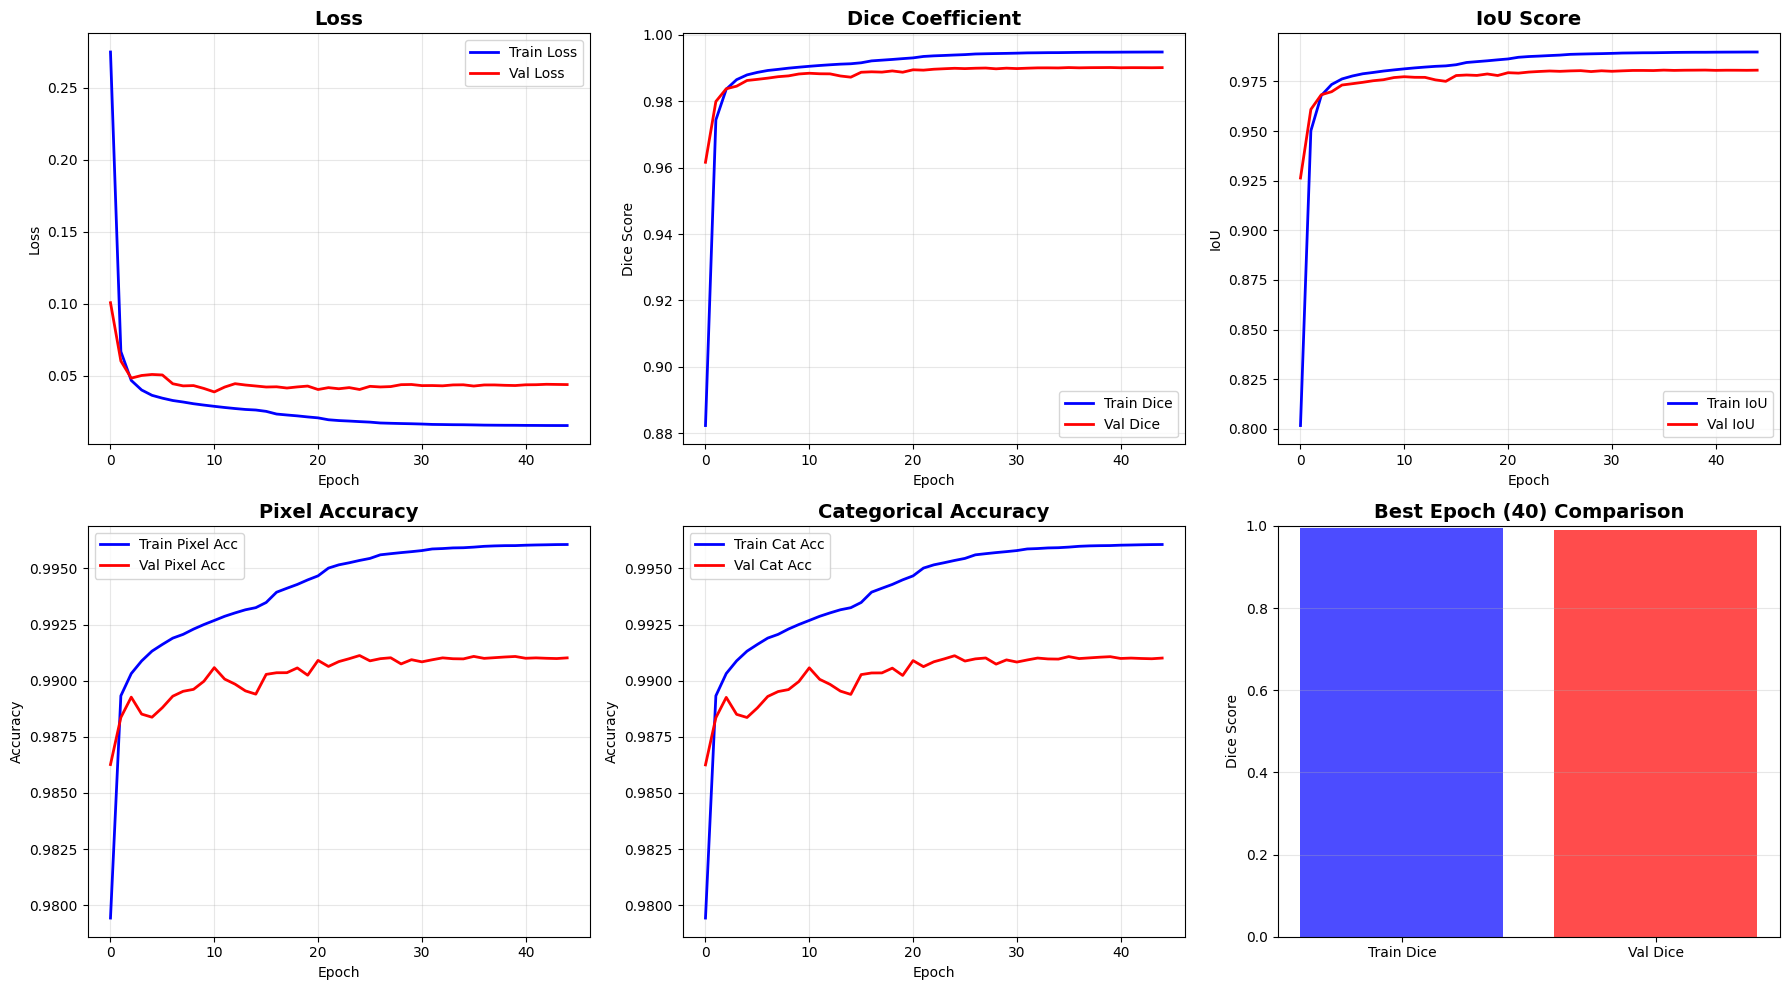


📊 BEST EPOCH: 40/50
   Val Dice: 0.9902
   Val IoU: 0.9807
   Val Loss: 0.0432
   Train Dice: 0.9948


In [16]:
def plot_training_curves(history):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Dice Coefficient
    axes[0, 1].plot(history.history['dice_coefficient'], label='Train Dice', linewidth=2, color='blue')
    axes[0, 1].plot(history.history['val_dice_coefficient'], label='Val Dice', linewidth=2, color='red')
    axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # IoU Score
    axes[0, 2].plot(history.history['iou_score'], label='Train IoU', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_iou_score'], label='Val IoU', linewidth=2, color='red')
    axes[0, 2].set_title('IoU Score', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('IoU')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Pixel Accuracy
    axes[1, 0].plot(history.history['pixel_accuracy'], label='Train Pixel Acc', linewidth=2, color='blue')
    axes[1, 0].plot(history.history['val_pixel_accuracy'], label='Val Pixel Acc', linewidth=2, color='red')
    axes[1, 0].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Categorical Accuracy
    axes[1, 1].plot(history.history['categorical_accuracy'], label='Train Cat Acc', linewidth=2, color='blue')
    axes[1, 1].plot(history.history['val_categorical_accuracy'], label='Val Cat Acc', linewidth=2, color='red')
    axes[1, 1].set_title('Categorical Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Training vs Validation Comparison
    best_epoch = np.argmax(history.history['val_dice_coefficient'])
    axes[1, 2].bar(['Train Dice', 'Val Dice'], 
                   [history.history['dice_coefficient'][best_epoch], 
                    history.history['val_dice_coefficient'][best_epoch]],
                   color=['blue', 'red'], alpha=0.7)
    axes[1, 2].set_title(f'Best Epoch ({best_epoch+1}) Comparison', fontsize=14, fontweight='bold')
    axes[1, 2].set_ylabel('Dice Score')
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot training curves
print("="*70)
print("PLOTTING TRAINING CURVES")
print("="*70)
plot_training_curves(history)

# Print best metrics
best_epoch = np.argmax(history.history['val_dice_coefficient'])
print(f"\n📊 BEST EPOCH: {best_epoch + 1}/{config.EPOCHS}")
print(f"   Val Dice: {history.history['val_dice_coefficient'][best_epoch]:.4f}")
print(f"   Val IoU: {history.history['val_iou_score'][best_epoch]:.4f}")
print(f"   Val Loss: {history.history['val_loss'][best_epoch]:.4f}")
print(f"   Train Dice: {history.history['dice_coefficient'][best_epoch]:.4f}")


# Load Best Model

In [17]:
# Load the best model
best_model = keras.models.load_model(
    '/kaggle/working/best_unet_model.h5',
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score': iou_score,
        'pixel_accuracy': pixel_accuracy
    }
)

print("="*70)
print("BEST MODEL LOADED")
print("="*70)
print("✅ Model loaded from: /kaggle/working/best_unet_model.h5")
print("="*70)

BEST MODEL LOADED
✅ Model loaded from: /kaggle/working/best_unet_model.h5


# Evaluation on Test Set

In [18]:
# Prepare test data
test_masks_categorical = tf.keras.utils.to_categorical(test_masks, num_classes=config.NUM_CLASSES)

# Evaluate on test set
print("="*70)
print("EVALUATING ON TEST SET")
print("="*70)
print(f"Test samples: {len(test_images):,}")
print(f"Test batches: {int(np.ceil(len(test_images) / config.BATCH_SIZE))}")
print("\nEvaluating...")

test_results = best_model.evaluate(
    test_images, 
    test_masks_categorical, 
    batch_size=config.BATCH_SIZE,
    verbose=1
)

print("\n" + "="*70)
print("TEST SET RESULTS (UNSEEN PATIENTS - NO DATA LEAKAGE!)")
print("="*70)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test IoU Score: {test_results[2]:.4f}")
print(f"Test Pixel Accuracy: {test_results[3]:.4f}")
print(f"Test Categorical Accuracy: {test_results[4]:.4f}")
print("="*70)

EVALUATING ON TEST SET
Test samples: 3,386
Test batches: 212

Evaluating...
212/212 ━━━━━━━━━━━━━━━━━━━━ 26s 107ms/step - categorical_accuracy: 0.9909 - dice_coefficient: 0.9901 - iou_score: 0.9805 - loss: 0.0439 - pixel_accuracy: 0.9909

TEST SET RESULTS (UNSEEN PATIENTS - NO DATA LEAKAGE!)
Test Loss: 0.0394
Test Dice Coefficient: 0.9909
Test IoU Score: 0.9821
Test Pixel Accuracy: 0.9917
Test Categorical Accuracy: 0.9917


# Make Predictions on Test Set

In [19]:
# Make predictions
print("="*70)
print("MAKING PREDICTIONS ON TEST SET")
print("="*70)

test_predictions = best_model.predict(test_images, batch_size=config.BATCH_SIZE, verbose=1)
test_predictions_classes = np.argmax(test_predictions, axis=-1)

print(f"\n✅ Predictions complete!")
print(f"Predictions shape: {test_predictions.shape}")
print(f"Predicted classes shape: {test_predictions_classes.shape}")
print(f"Unique predicted classes: {np.unique(test_predictions_classes)}")
print("="*70)

MAKING PREDICTIONS ON TEST SET
212/212 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step

✅ Predictions complete!
Predictions shape: (3386, 128, 128, 4)
Predicted classes shape: (3386, 128, 128)
Unique predicted classes: [0 1 2 3]


# Visualize Predictions

VISUALIZING TEST SET PREDICTIONS


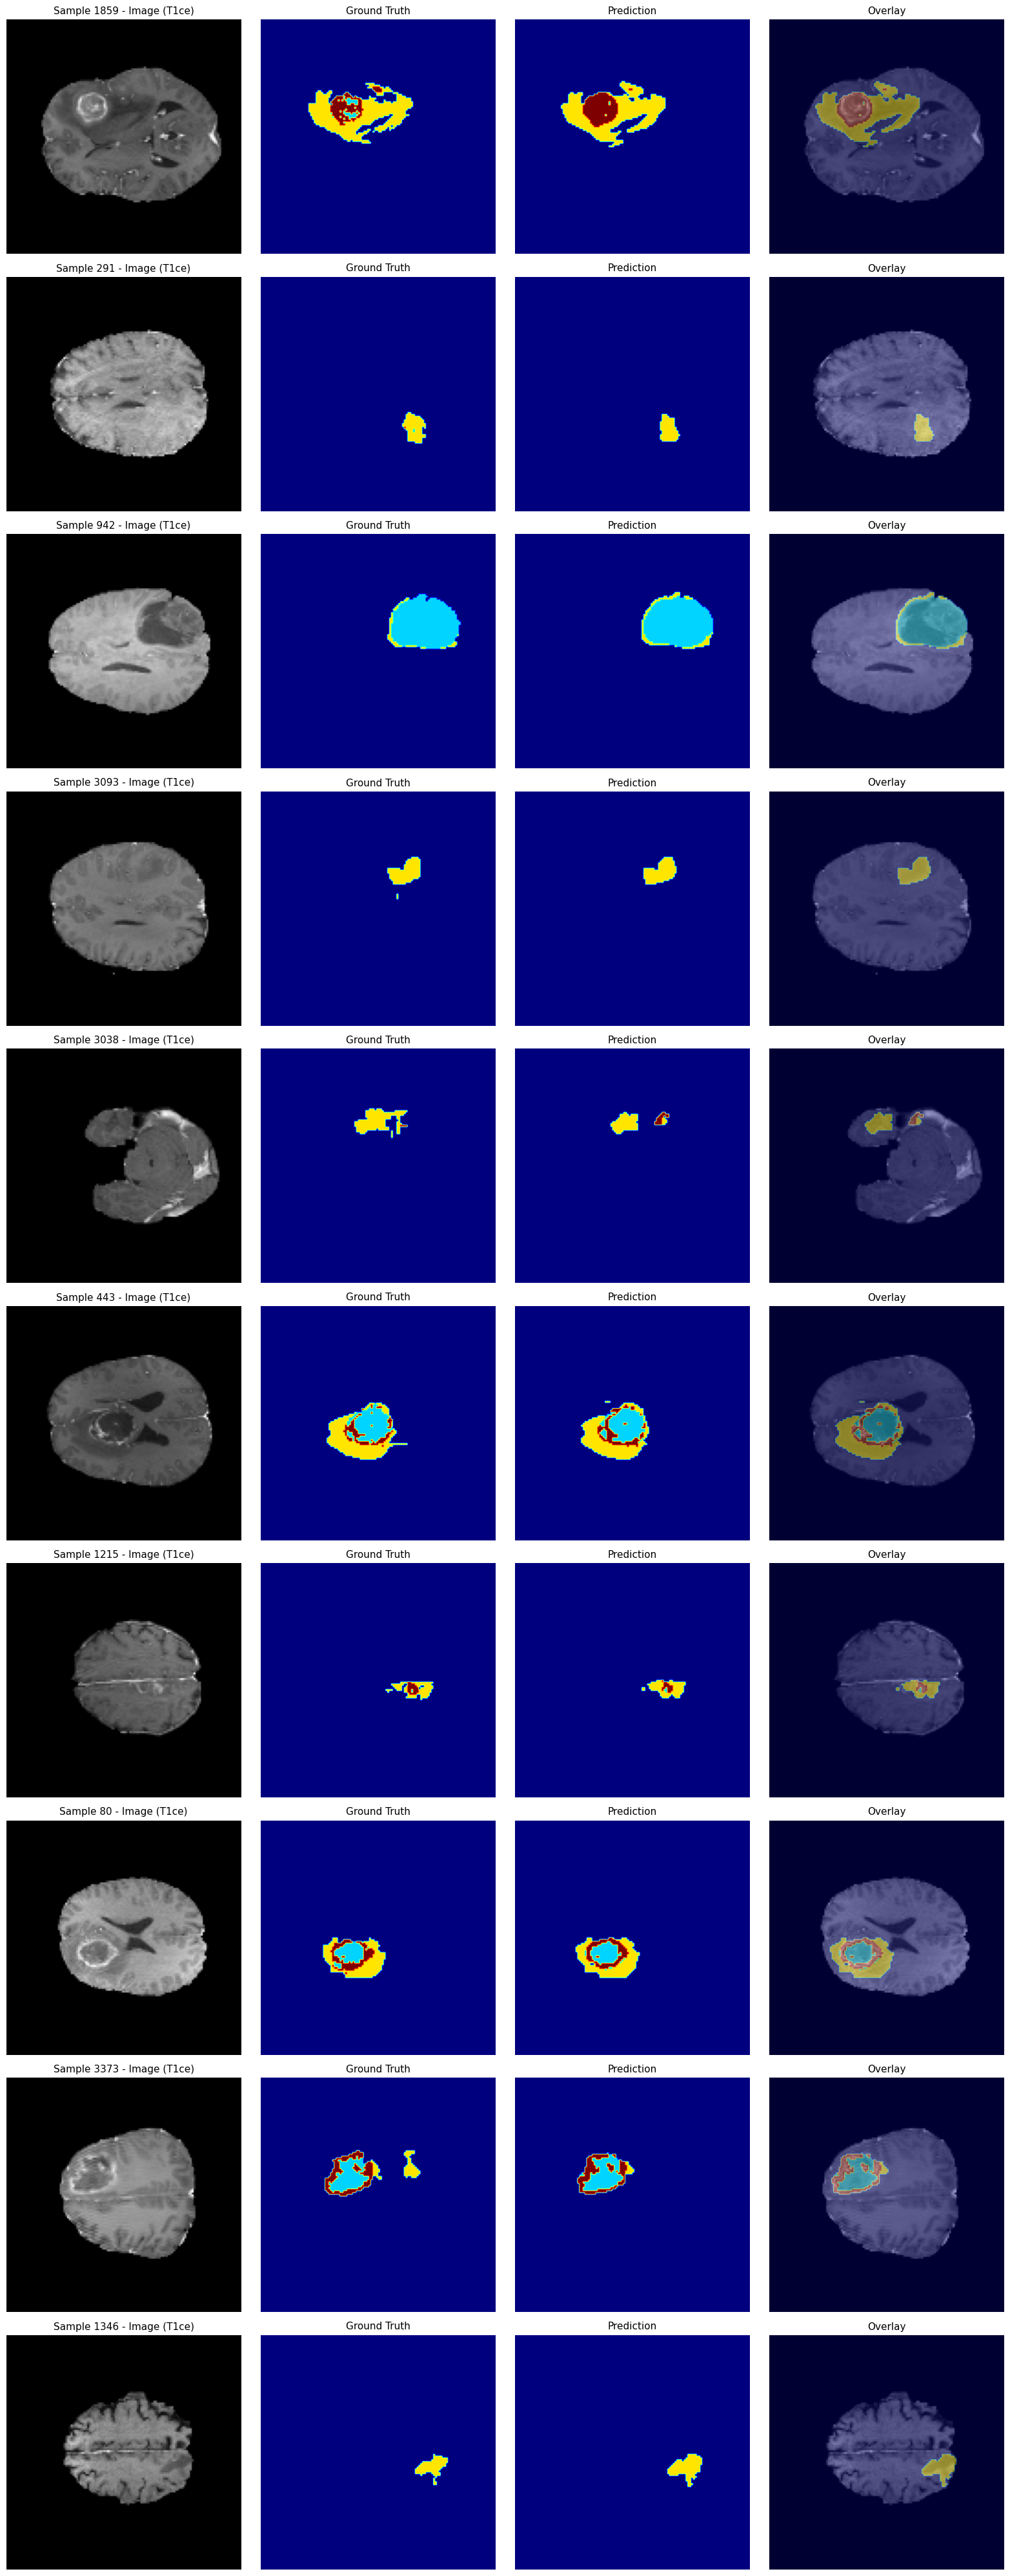

In [20]:
def visualize_predictions(images, true_masks, pred_masks, num_samples=10):
    """Visualize predictions"""
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i, idx in enumerate(indices):
        # Original image (T1ce channel)
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'Sample {idx} - Image (T1ce)', fontsize=11)
        axes[i, 0].axis('off')
        
        # Ground truth mask
        axes[i, 1].imshow(true_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth', fontsize=11)
        axes[i, 1].axis('off')
        
        # Predicted mask
        axes[i, 2].imshow(pred_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 2].set_title('Prediction', fontsize=11)
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 3].imshow(pred_masks[idx], cmap='jet', alpha=0.4, vmin=0, vmax=3)
        axes[i, 3].set_title('Overlay', fontsize=11)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/test_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize predictions
print("="*70)
print("VISUALIZING TEST SET PREDICTIONS")
print("="*70)
visualize_predictions(test_images, test_masks, test_predictions_classes, num_samples=10)

# Error Maps

VISUALIZING ERROR MAPS


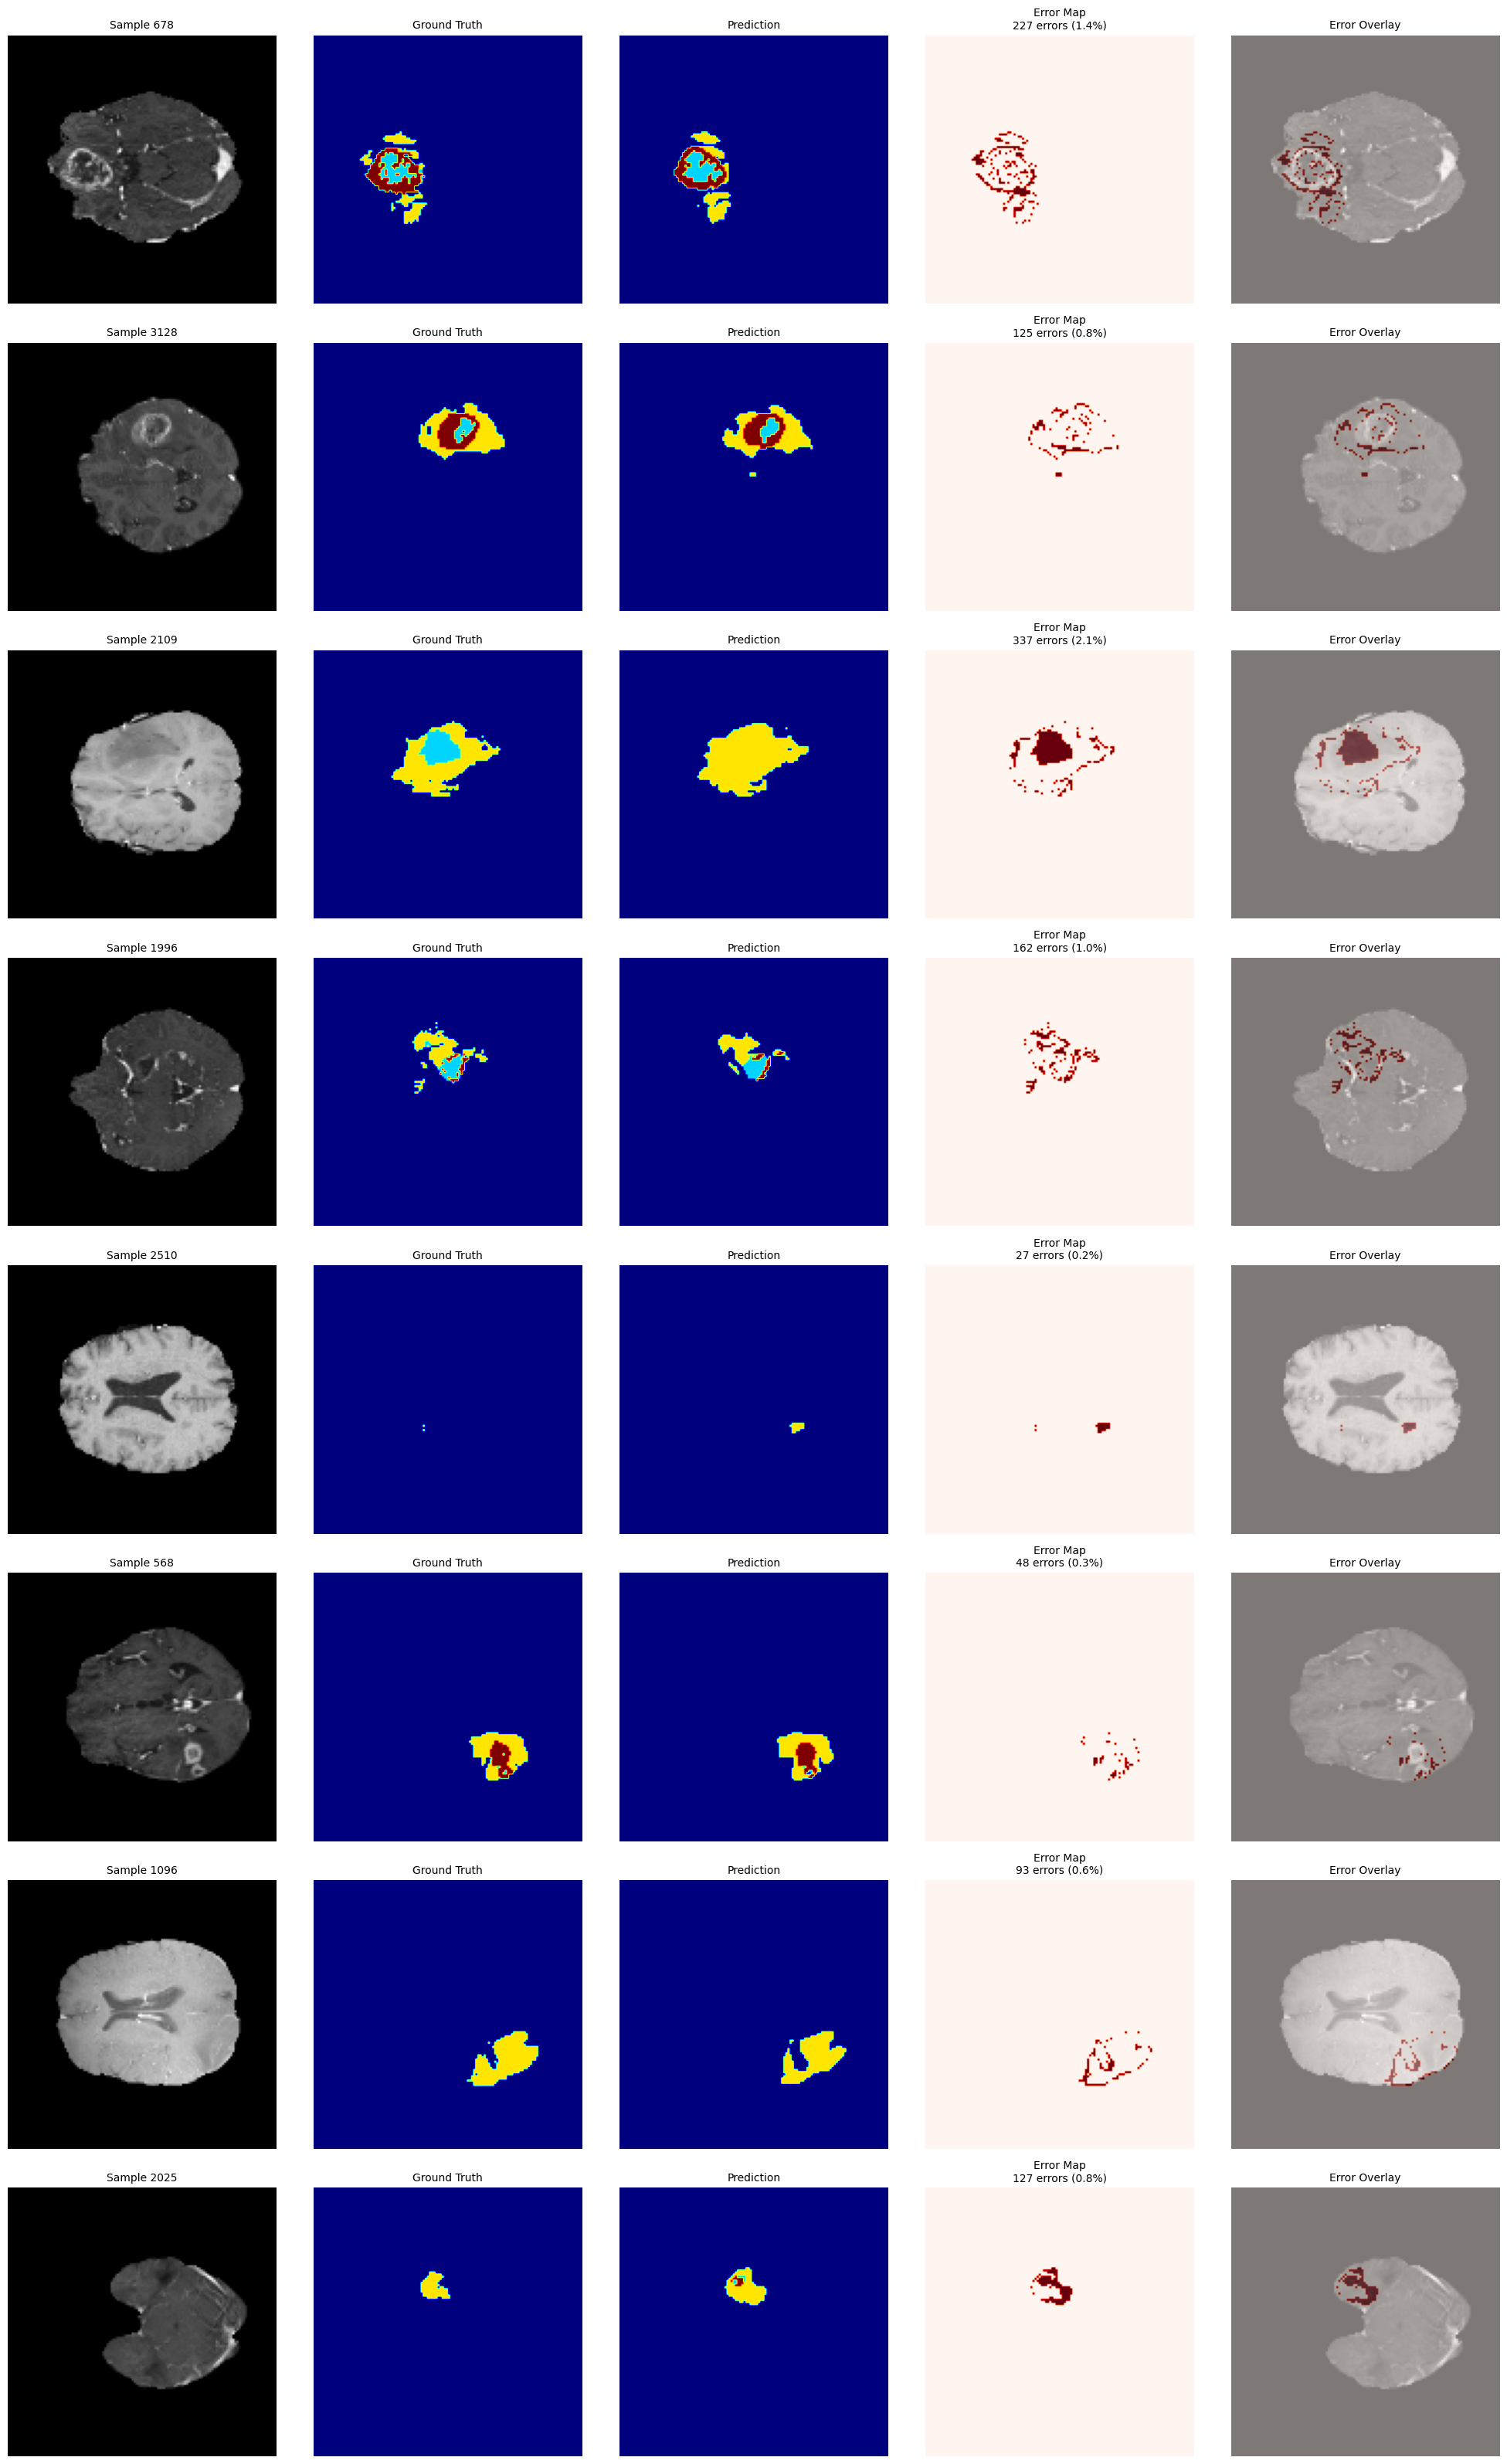


📊 ERROR STATISTICS:
   Total pixels: 55,476,224
   Incorrect pixels: 458,817
   Error rate: 0.83%
   Pixel accuracy: 99.17%


In [21]:
def visualize_error_maps(images, true_masks, pred_masks, num_samples=8):
    """Visualize error/difference maps"""
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    
    for i, idx in enumerate(indices):
        # Original image
        axes[i, 0].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 0].set_title(f'Sample {idx}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(true_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred_masks[idx], cmap='jet', vmin=0, vmax=3)
        axes[i, 2].set_title('Prediction', fontsize=10)
        axes[i, 2].axis('off')
        
        # Error map
        error_map = (true_masks[idx] != pred_masks[idx]).astype(np.uint8)
        error_count = np.sum(error_map)
        total_pixels = error_map.size
        error_pct = (error_count / total_pixels) * 100
        
        axes[i, 3].imshow(error_map, cmap='Reds', vmin=0, vmax=1)
        axes[i, 3].set_title(f'Error Map\n{error_count} errors ({error_pct:.1f}%)', fontsize=10)
        axes[i, 3].axis('off')
        
        # Overlay error on image
        axes[i, 4].imshow(images[idx][:, :, 1], cmap='gray')
        axes[i, 4].imshow(error_map, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 4].set_title('Error Overlay', fontsize=10)
        axes[i, 4].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/error_maps.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize error maps
print("="*70)
print("VISUALIZING ERROR MAPS")
print("="*70)
visualize_error_maps(test_images, test_masks, test_predictions_classes, num_samples=8)

# Calculate overall error statistics
total_pixels = test_masks.size
error_pixels = np.sum(test_masks != test_predictions_classes)
error_rate = (error_pixels / total_pixels) * 100

print(f"\n📊 ERROR STATISTICS:")
print(f"   Total pixels: {total_pixels:,}")
print(f"   Incorrect pixels: {error_pixels:,}")
print(f"   Error rate: {error_rate:.2f}%")
print(f"   Pixel accuracy: {100-error_rate:.2f}%")
print("="*70)

# Class-wise Metrics

CLASS-WISE EVALUATION METRICS
Class           Dice Score      IoU Score      
----------------------------------------------------------------------
Background      0.9973          0.9945         
Necrotic        0.7611          0.6143         
Edema           0.8187          0.6930         
Enhancing       0.7801          0.6394         
----------------------------------------------------------------------
Mean            0.8393          0.7353         


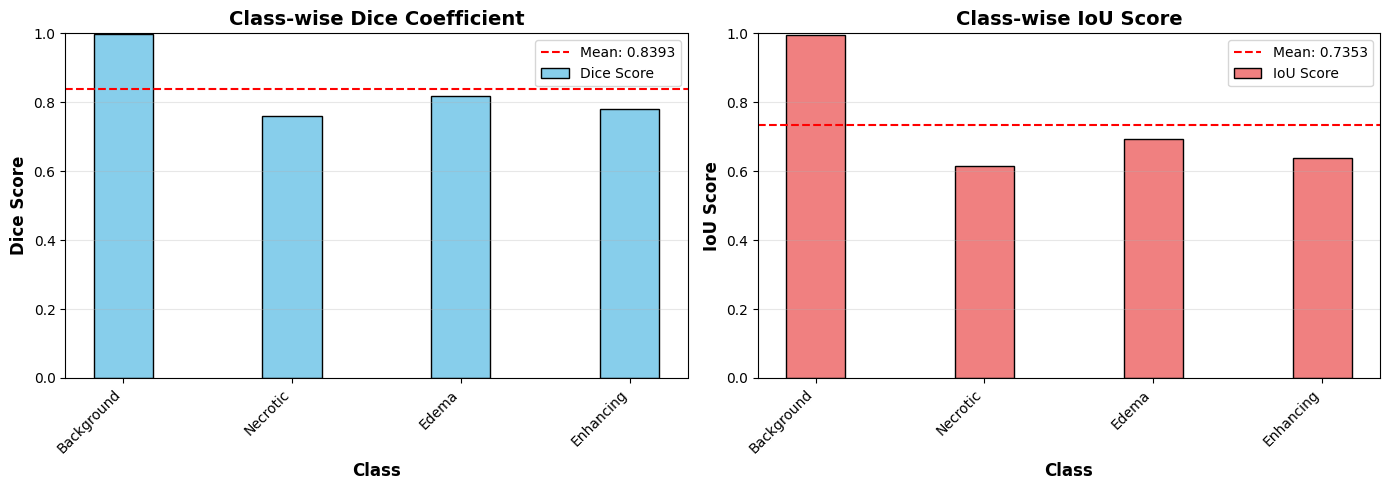

In [22]:
def calculate_class_wise_metrics(true_masks, pred_masks, num_classes=4):
    """Calculate class-wise Dice and IoU"""
    dice_scores = []
    iou_scores = []
    
    for class_id in range(num_classes):
        true_binary = (true_masks == class_id).astype(np.float32)
        pred_binary = (pred_masks == class_id).astype(np.float32)
        
        intersection = np.sum(true_binary * pred_binary)
        true_sum = np.sum(true_binary)
        pred_sum = np.sum(pred_binary)
        union = true_sum + pred_sum - intersection
        
        # Dice
        if true_sum + pred_sum > 0:
            dice = (2 * intersection) / (true_sum + pred_sum)
        else:
            dice = 1.0
        
        # IoU
        if union > 0:
            iou = intersection / union
        else:
            iou = 1.0
        
        dice_scores.append(dice)
        iou_scores.append(iou)
    
    return dice_scores, iou_scores

# Calculate metrics
class_dice, class_iou = calculate_class_wise_metrics(test_masks, test_predictions_classes, config.NUM_CLASSES)
class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

print("="*70)
print("CLASS-WISE EVALUATION METRICS")
print("="*70)
print(f"{'Class':<15} {'Dice Score':<15} {'IoU Score':<15}")
print("-"*70)
for i, name in enumerate(class_names):
    print(f"{name:<15} {class_dice[i]:<15.4f} {class_iou[i]:<15.4f}")
print("-"*70)
print(f"{'Mean':<15} {np.mean(class_dice):<15.4f} {np.mean(class_iou):<15.4f}")
print("="*70)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(class_names))
width = 0.35

axes[0].bar(x, class_dice, width, label='Dice Score', color='skyblue', edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Dice Score', fontsize=12, fontweight='bold')
axes[0].set_title('Class-wise Dice Coefficient', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=np.mean(class_dice), color='red', linestyle='--', label=f'Mean: {np.mean(class_dice):.4f}')
axes[0].legend()

axes[1].bar(x, class_iou, width, label='IoU Score', color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('IoU Score', fontsize=12, fontweight='bold')
axes[1].set_title('Class-wise IoU Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=np.mean(class_iou), color='red', linestyle='--', label=f'Mean: {np.mean(class_iou):.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/classwise_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix

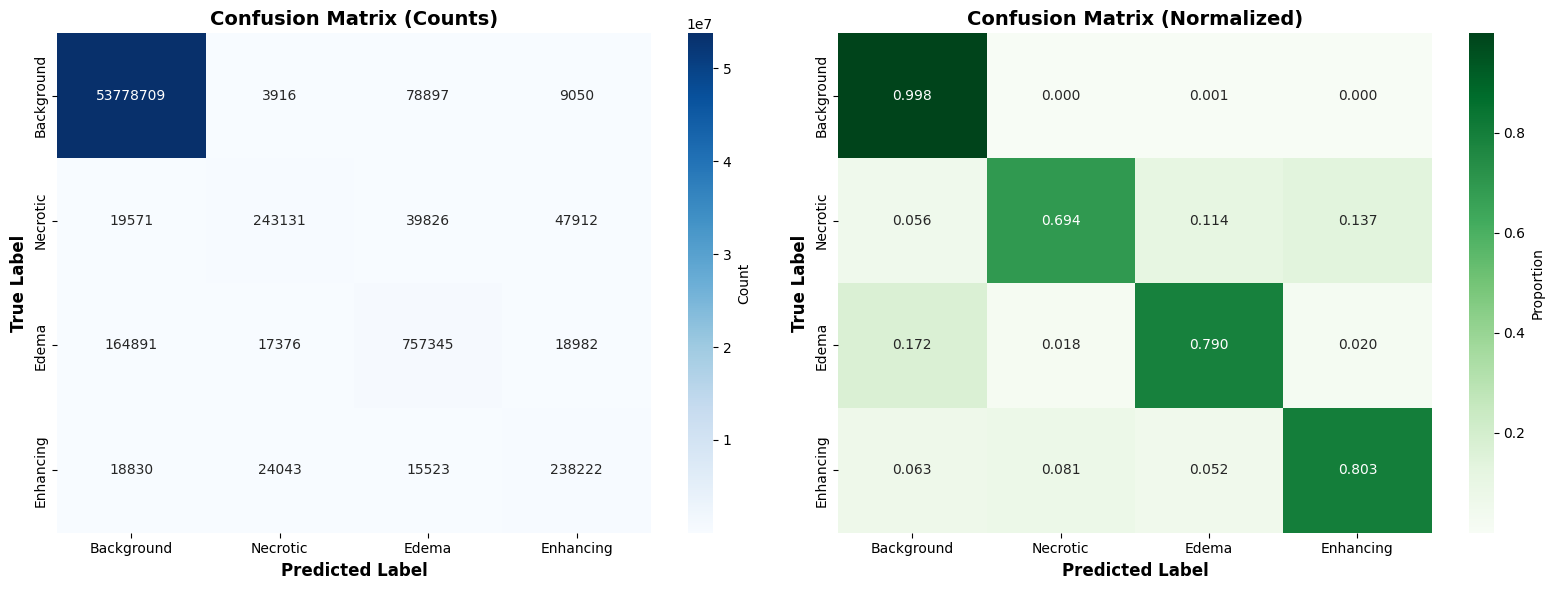

CONFUSION MATRIX SAVED


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(test_masks.flatten(), test_predictions_classes.flatten())
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print("CONFUSION MATRIX SAVED")
print("="*70)

#  Comprehensive Metrics

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9962    0.9983    0.9973  53870572
    Necrotic     0.8428    0.6938    0.7611    350440
       Edema     0.8494    0.7901    0.8187    958594
   Enhancing     0.7583    0.8031    0.7801    296618

    accuracy                         0.9917  55476224
   macro avg     0.8617    0.8213    0.8393  55476224
weighted avg     0.9915    0.9917    0.9915  55476224


COMPREHENSIVE METRICS SUMMARY
     Class     Dice      IoU  Precision   Recall  F1-Score
Background 0.997263 0.994542   0.996234 0.998295  0.997263
  Necrotic 0.761085 0.614316   0.842841 0.693788  0.761085
     Edema 0.818669 0.693006   0.849431 0.790058  0.818669
 Enhancing 0.780053 0.639416   0.758268 0.803127  0.780053

✅ Metrics saved to 'evaluation_metrics.csv'


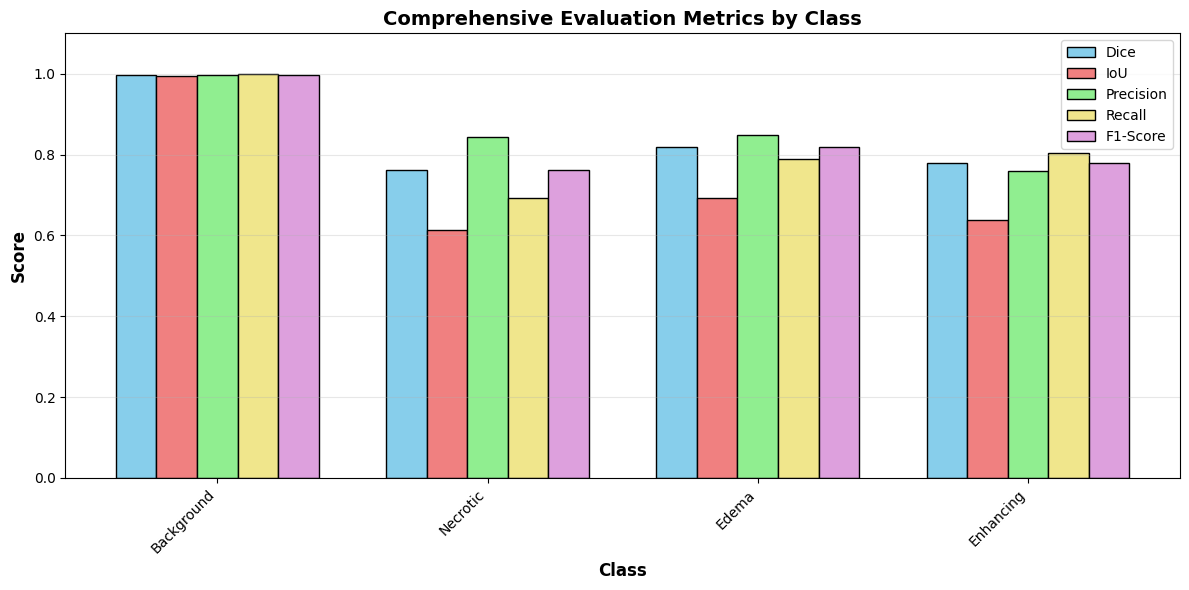

In [24]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Flatten arrays
y_true = test_masks.flatten()
y_pred = test_predictions_classes.flatten()

# Calculate metrics
precision = precision_score(y_true, y_pred, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

print("="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Summary table
summary_data = {
    'Class': class_names,
    'Dice': class_dice,
    'IoU': class_iou,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save to CSV
summary_df.to_csv('/kaggle/working/evaluation_metrics.csv', index=False)
print("\n✅ Metrics saved to 'evaluation_metrics.csv'")

# Visualize all metrics
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.15

ax.bar(x - 2*width, class_dice, width, label='Dice', color='skyblue', edgecolor='black')
ax.bar(x - width, class_iou, width, label='IoU', color='lightcoral', edgecolor='black')
ax.bar(x, precision, width, label='Precision', color='lightgreen', edgecolor='black')
ax.bar(x + width, recall, width, label='Recall', color='khaki', edgecolor='black')
ax.bar(x + 2*width, f1, width, label='F1-Score', color='plum', edgecolor='black')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comprehensive Evaluation Metrics by Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim([0, 1.1])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/comprehensive_metrics.png', dpi=300, bbox_inches='tight')
plt.show()